In [34]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from onnx import ModelProto
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

In [35]:
df = pd.read_csv("../data/Dataset_v2.csv")

In [36]:
df["url"] = df['url'].str.replace('www.', '')

In [37]:
df.head()

,url,label,dom_len,is_ip,tld_len,subdom_cnt,has_www,entropy,dom_digit_ratio,dom_letter_ratio,is_https
0,https://rmit.edu.au/,0,6.0,0.0,2.0,1.0,1.0,3.095795,0.0,1.0,1.0
1,http://latrobe.edu.au/,0,6.0,0.0,2.0,1.0,1.0,3.235926,0.0,1.0,0.0
2,https://cqu.edu.au/,0,6.0,0.0,2.0,1.0,1.0,2.646439,0.0,1.0,1.0
3,http://bond.edu.au/,0,6.0,0.0,2.0,1.0,0.0,2.913977,0.0,1.0,0.0
4,http://csu.edu.au/,0,6.0,0.0,2.0,1.0,1.0,2.646439,0.0,1.0,0.0


In [38]:
print(df["label"].value_counts(normalize=True))

label
0    0.857633
1    0.142367
Name: proportion, dtype: float64


In [39]:
len(df[df["label"] == 1])

16600

In [40]:
X = df.drop(columns=["url", "label", "has_www"])
y = df["label"]

In [41]:
def train_and_score(model, X, y):
    scores = cross_val_score(model, X, y, cv=4)
    min_acc_threshold = 0.9
    if scores.mean() < min_acc_threshold:
        print(
            f"{model.__class__.__name__} accuracy {scores.mean()} (less than {min_acc_threshold}). Stop training"
        )
        return

    print(
        f"{model.__class__.__name__} mean accuracy:\n{scores.mean():.3f} ± {scores.std():.3f}"
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(
        classification_report(
            y_test, y_pred, target_names=["safe", "phishing"], digits=4
        )
    )
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["safe", "phishing"], normalize="true"
    )

    if hasattr(model, "feature_importances_"):
        importance_df = pd.DataFrame(
            {"feature": X.columns, "importance": model.feature_importances_}
        ).sort_values("importance", ascending=False)

        print(importance_df)

    model.fit(X, y)

In [42]:
decision_tree = DecisionTreeClassifier(random_state=42)

DecisionTreeClassifier mean accuracy:
0.931 ± 0.019
              precision    recall  f1-score   support

        safe     0.9605    0.9790    0.9697     19976
    phishing     0.8584    0.7593    0.8058      3344

    accuracy                         0.9475     23320
   macro avg     0.9094    0.8691    0.8877     23320
weighted avg     0.9458    0.9475    0.9462     23320

            feature  importance
4           entropy    0.357041
0           dom_len    0.294594
7          is_https    0.143227
3        subdom_cnt    0.092588
2           tld_len    0.091451
6  dom_letter_ratio    0.013226
5   dom_digit_ratio    0.007873
1             is_ip    0.000000


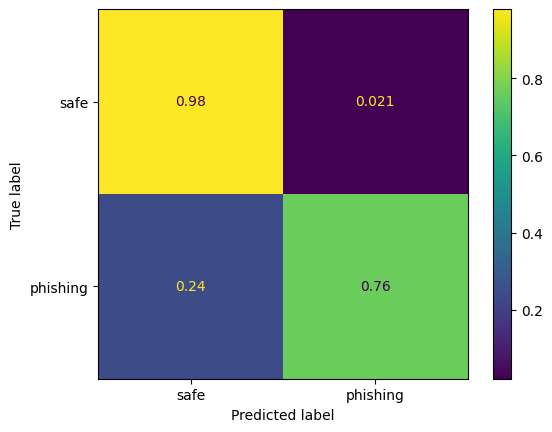

In [43]:
train_and_score(decision_tree, X, y)

In [44]:
initial_type = [('float_input', FloatTensorType([None, X.shape[1]]))]
onx = convert_sklearn(decision_tree, initial_types=initial_type, target_opset=14, options={'zipmap': False})

In [45]:
import os

In [46]:
assert isinstance(onx, ModelProto)

os.makedirs("../output", exist_ok=True)
with open("../output/phish_model.onnx", "wb") as f:
    f.write(onx.SerializeToString())

print(f"✅ Exported: phish_model.onnx ({onx.ByteSize() / 1024:.1f} KB)")

✅ Exported: phish_model.onnx (261.6 KB)


In [47]:
test_df = pd.read_csv("../data/test_df.csv")

In [48]:
decision_tree.predict(test_df.drop(columns=["url", "has_www"]))

array([0, 0, 0, 0])